In [1]:
import pandas as pd

# Load both CSV files
df1 = pd.read_csv('../data/raw/Cleaned_Unemployment_in_India.csv')
df2 = pd.read_csv('../data/raw/Cleaned_Unemployment_Rate_upto_11_2020.csv')

# First few rows
print("Dataset 1:")
print(df1.head())

print("\nDataset 2:")
print(df2.head())

# Column names
print("Dataset 1 columns:", df1.columns)
print("Dataset 2 columns:", df2.columns)

# Missing values
print("Dataset 1 missing values:\n", df1.isnull().sum())
print("Dataset 2 missing values:\n", df2.isnull().sum())


Dataset 1:
           region        date frequency  estimated_unemployment_rate_percent  \
0  Andhra Pradesh  2019-05-31   Monthly                                 3.65   
1  Andhra Pradesh  2019-06-30   Monthly                                 3.05   
2  Andhra Pradesh  2019-07-31   Monthly                                 3.75   
3  Andhra Pradesh  2019-08-31   Monthly                                 3.32   
4  Andhra Pradesh  2019-09-30   Monthly                                 5.17   

   estimated_employed  estimated_labour_participation_rate_percent   area  
0          11999139.0                                        43.24  Rural  
1          11755881.0                                        42.05  Rural  
2          12086707.0                                        43.50  Rural  
3          12285693.0                                        43.97  Rural  
4          12256762.0                                        44.68  Rural  

Dataset 2:
           region        date frequency 

In [3]:
import pandas as pd

# Load datasets
df1 = pd.read_csv('../data/raw/Cleaned_Unemployment_in_India.csv')
df2 = pd.read_csv('../data/raw/Cleaned_Unemployment_Rate_upto_11_2020.csv')

# --- Dataset 1 Cleaning ---
# Convert date to datetime
df1['date'] = pd.to_datetime(df1['date'])

# Check missing values
print("Missing values in Dataset 1:\n", df1.isnull().sum())

# Fill or drop missing values if needed (example: drop rows with any missing)
df1_cleaned = df1.dropna().copy()

# --- Dataset 2 Cleaning ---
# Drop unnecessary columns
columns_to_drop = ['region.1', 'longitude', 'latitude']  # adjust if needed
df2 = df2.drop(columns=[col for col in columns_to_drop if col in df2.columns])

# Convert date to datetime
df2['date'] = pd.to_datetime(df2['date'])

# Standardize frequency column (optional)
df2['frequency'] = df2['frequency'].replace({'M':'Monthly'})

# Check missing values
print("Missing values in Dataset 2:\n", df2.isnull().sum())

# Drop rows with missing values
df2_cleaned = df2.dropna().copy()

# --- Optional: Save cleaned datasets ---
df1_cleaned.to_csv('../data/cleaned/Cleaned_Unemployment_in_India_cleaned.csv', index=False)
df2_cleaned.to_csv('../data/cleaned/Cleaned_Unemployment_Rate_upto_11_2020_cleaned.csv', index=False)

print("Data cleaning done! Cleaned files saved in 'data/cleaned/' folder.")


Missing values in Dataset 1:
 region                                         0
date                                           0
frequency                                      0
estimated_unemployment_rate_percent            0
estimated_employed                             0
estimated_labour_participation_rate_percent    0
area                                           0
dtype: int64
Missing values in Dataset 2:
 region                                         0
date                                           0
frequency                                      0
estimated_unemployment_rate_percent            0
estimated_employed                             0
estimated_labour_participation_rate_percent    0
dtype: int64
Data cleaning done! Cleaned files saved in 'data/cleaned/' folder.


In [4]:
# Assuming df1_cleaned and df2_cleaned are your cleaned datasets
# Concatenate them vertically (stack rows)
merged_df = pd.concat([df1_cleaned, df2_cleaned], ignore_index=True)

# Optional: sort by region and date
merged_df = merged_df.sort_values(by=['region', 'date']).reset_index(drop=True)

# Check merged data
print(merged_df.head())
print(merged_df.tail())

# Save merged dataset
merged_df.to_csv('../data/cleaned/merged_unemployment_data.csv', index=False)
print("Merged dataset saved as 'merged_unemployment_data.csv'")


           region       date frequency  estimated_unemployment_rate_percent  \
0  Andhra Pradesh 2019-05-31   Monthly                                 3.65   
1  Andhra Pradesh 2019-05-31   Monthly                                 6.09   
2  Andhra Pradesh 2019-06-30   Monthly                                 3.05   
3  Andhra Pradesh 2019-06-30   Monthly                                 3.80   
4  Andhra Pradesh 2019-07-31   Monthly                                 3.75   

   estimated_employed  estimated_labour_participation_rate_percent   area  
0          11999139.0                                        43.24  Rural  
1           4788661.0                                        37.45  Urban  
2          11755881.0                                        42.05  Rural  
3           4824630.0                                        36.76  Urban  
4          12086707.0                                        43.50  Rural  
           region       date frequency  estimated_unemployment_rate_p

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the merged dataset (if not already in memory)
merged_df = pd.read_csv('../data/cleaned/merged_unemployment_data.csv')

# --- Step 1: Select Features (X) and Target (y) ---
# For example, predict 'estimated_unemployment_rate_percent' using 'estimated_employed' and 'estimated_labour_participation_rate_percent'
features = ['estimated_employed', 'estimated_labour_participation_rate_percent']
target = 'estimated_unemployment_rate_percent'

X = merged_df[features]
y = merged_df[target]

# --- Step 2: Split into train and test sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 3: Train Linear Regression Model ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# --- Step 4: Make Predictions ---
y_pred = lr_model.predict(X_test)

# --- Step 5: Evaluate the Model ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

# --- Optional: Check coefficients ---
coefficients = pd.DataFrame({'Feature': features, 'Coefficient': lr_model.coef_})
print(coefficients)


Mean Squared Error (MSE): 82.48
R^2 Score: 0.05
                                       Feature   Coefficient
0                           estimated_employed -2.261455e-07
1  estimated_labour_participation_rate_percent -2.405447e-02


Mean Squared Error (MSE): 45.79
R^2 Score: 0.47


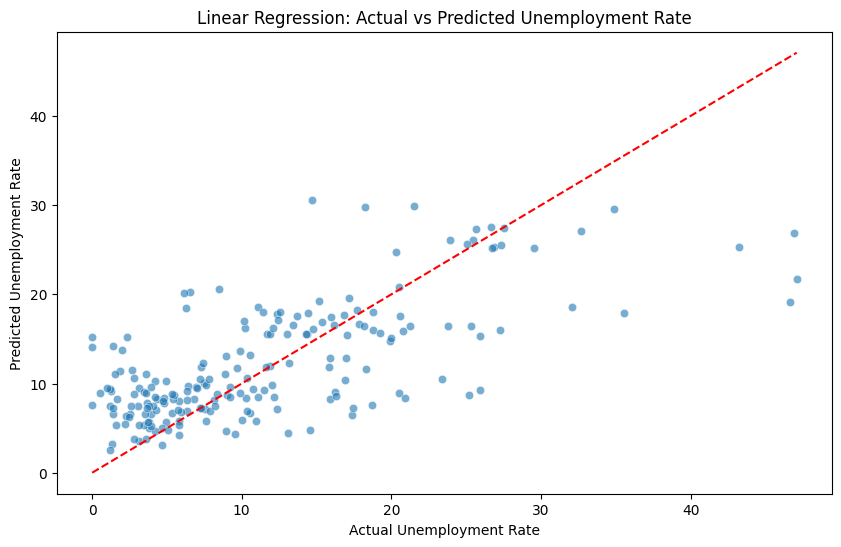

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load merged dataset
merged_df = pd.read_csv('../data/cleaned/merged_unemployment_data.csv')

# --- Step 1: Prepare features and target ---
# Include categorical features
features = ['estimated_employed', 'estimated_labour_participation_rate_percent', 'region', 'area']
target = 'estimated_unemployment_rate_percent'

# One-hot encode categorical features
X = pd.get_dummies(merged_df[features], drop_first=True)
y = merged_df[target]

# --- Step 2: Split into train and test sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 3: Train Linear Regression Model ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# --- Step 4: Make Predictions ---
y_pred = lr_model.predict(X_test)

# --- Step 5: Evaluate the Model ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

# --- Step 6: Visualize Predictions vs Actual ---
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Unemployment Rate")
plt.ylabel("Predicted Unemployment Rate")
plt.title("Linear Regression: Actual vs Predicted Unemployment Rate")
plt.show()



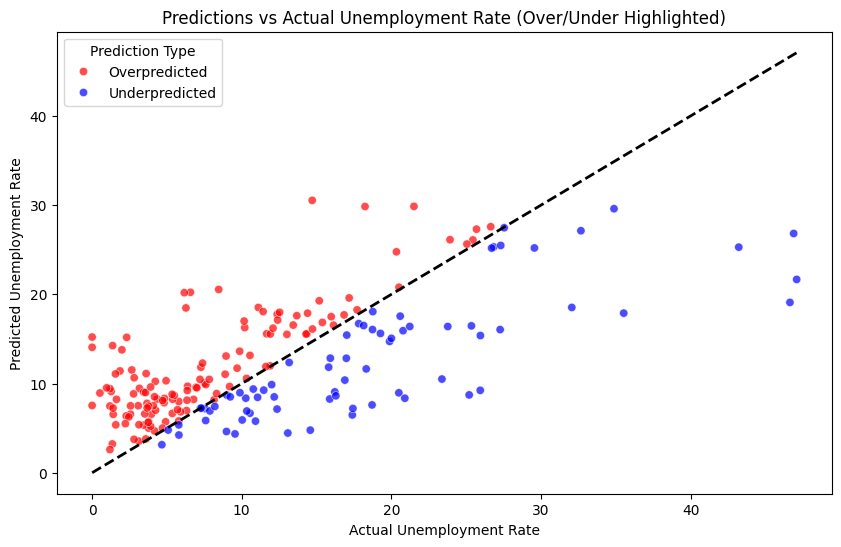

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame of actual vs predicted
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# Define over/under prediction
results['Error_Type'] = results.apply(lambda row: 'Overpredicted' if row['Predicted'] > row['Actual'] else 'Underpredicted', axis=1)

# Plot
plt.figure(figsize=(10,6))
sns.scatterplot(x='Actual', y='Predicted', hue='Error_Type', data=results, alpha=0.7, palette={'Overpredicted':'red', 'Underpredicted':'blue'})
plt.plot([results['Actual'].min(), results['Actual'].max()],
         [results['Actual'].min(), results['Actual'].max()],
         'k--', lw=2)  # perfect prediction line
plt.xlabel("Actual Unemployment Rate")
plt.ylabel("Predicted Unemployment Rate")
plt.title("Predictions vs Actual Unemployment Rate (Over/Under Highlighted)")
plt.legend(title='Prediction Type')
plt.show()


Random Forest MSE: 26.44
Random Forest R² Score: 0.70


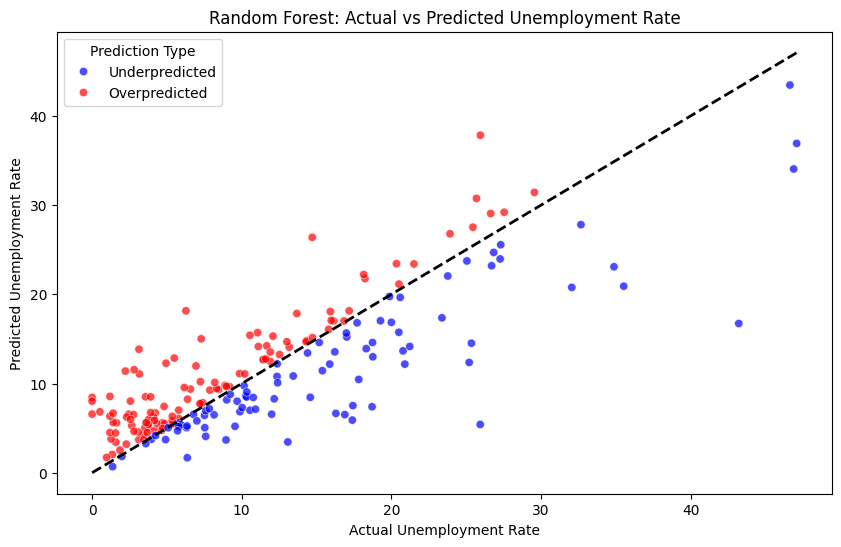

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load merged dataset
merged_df = pd.read_csv('../data/cleaned/merged_unemployment_data.csv')

# --- Step 1: Prepare features and target ---
features = ['estimated_employed', 'estimated_labour_participation_rate_percent', 'region', 'area']
target = 'estimated_unemployment_rate_percent'

# One-hot encode categorical features
X = pd.get_dummies(merged_df[features], drop_first=True)
y = merged_df[target]

# --- Step 2: Split into train and test sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 3: Train Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# --- Step 4: Make Predictions ---
y_pred = rf_model.predict(X_test)

# --- Step 5: Evaluate Model ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Random Forest MSE: {mse:.2f}")
print(f"Random Forest R² Score: {r2:.2f}")

# --- Step 6: Visualize Predictions ---
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results['Error_Type'] = results.apply(lambda row: 'Overpredicted' if row['Predicted'] > row['Actual'] else 'Underpredicted', axis=1)

plt.figure(figsize=(10,6))
sns.scatterplot(x='Actual', y='Predicted', hue='Error_Type', data=results, alpha=0.7, palette={'Overpredicted':'red', 'Underpredicted':'blue'})
plt.plot([results['Actual'].min(), results['Actual'].max()],
         [results['Actual'].min(), results['Actual'].max()],
         'k--', lw=2)  # perfect prediction line
plt.xlabel("Actual Unemployment Rate")
plt.ylabel("Predicted Unemployment Rate")
plt.title("Random Forest: Actual vs Predicted Unemployment Rate")
plt.legend(title='Prediction Type')
plt.show()


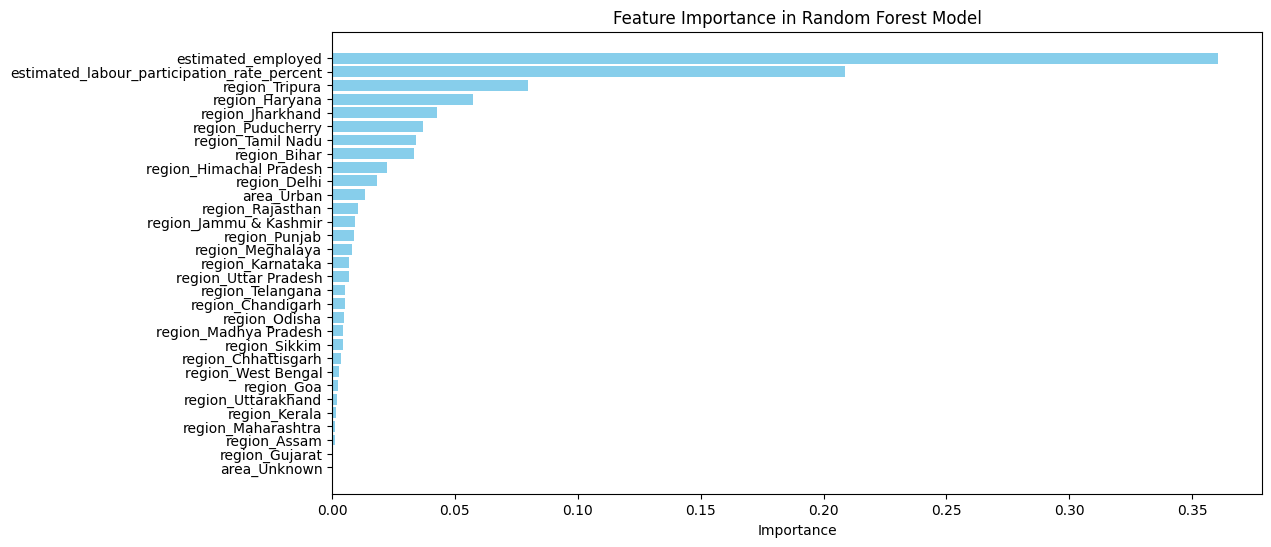

In [6]:
import matplotlib.pyplot as plt

# Get feature importances from the Random Forest model
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for plotting
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12,6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # largest importance on top
plt.show()


In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Initialize Random Forest
rf = RandomForestRegressor(random_state=42)

# Grid search with 3-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='r2')
grid_search.fit(X_train, y_train)

# Best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best R² Score:", grid_search.best_score_)

# Use the best estimator
best_rf_model = grid_search.best_estimator_


Best Parameters: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 300}
Best R² Score: 0.5128267643485637


In [1]:
import os

# Create 'models' folder if it doesn't exist
os.makedirs('../models', exist_ok=True)


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Load merged dataset
merged_df = pd.read_csv('../data/cleaned/merged_unemployment_data.csv')

# Prepare features and target
features = ['estimated_employed', 'estimated_labour_participation_rate_percent', 'region', 'area']
target = 'estimated_unemployment_rate_percent'
X = pd.get_dummies(merged_df[features], drop_first=True)
y = merged_df[target]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
best_rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
best_rf_model.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [4]:
import os
import joblib

# Ensure 'models' folder exists
os.makedirs('../models', exist_ok=True)

# Save the model
joblib.dump(best_rf_model, '../models/random_forest_unemployment.pkl')
print("Model saved successfully!")


Model saved successfully!


In [5]:
import joblib

# Load the trained Random Forest model
loaded_model = joblib.load('../models/random_forest_unemployment.pkl')
print("Model loaded successfully!")


Model loaded successfully!


In [6]:
# Predict using the loaded model
y_pred_loaded = loaded_model.predict(X_test)

# View first 5 predictions
print(y_pred_loaded[:5])


[ 3.75325 15.7468  12.49845  8.555   13.66175]
